<a href="https://colab.research.google.com/github/pop756/Quantum_KAN/blob/EMT/Real_backend.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
""" 
!git clone -b EMT https://github.com/pop756/Quantum_KAN.git
%cd Quantum_KAN
!pip install -r requirements.txt """

' \n!git clone -b EMT https://github.com/pop756/Quantum_KAN.git\n%cd Quantum_KAN\n!pip install -r requirements.txt '

In [1]:
def calculate_angle(norm,imag):
    if norm > 0:
        sign = 1
    else:
        sign = -1
    real = sign*np.sqrt(norm**2-imag**2)
    angle = np.arctan(imag/real)
    return angle

In [21]:
# Initialize your account
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
from qiskit.circuit.library import RealAmplitudes, EfficientSU2

service = QiskitRuntimeService(
    channel="ibm_quantum",
    instance="ibm-q-skku/skku/skku-students",
    token="89bf940a345d0ebd670b0be467af497a64ef3d2c72fde2f0f17e74e06cf939ffb291e0af343bde0ca205b7acf60501db4e0e5cfcac468ce19a7fca432d2fbac5",
)
backend = service.backend('ibm_strasbourg')



In [22]:
backend.target['ecr'][(78,77)].calibration.instructions[0][1].pulse._params

{'sigma': 32,
 'width': 472,
 'amp': 0.03423285847646341,
 'angle': -0.002394413238397934}

In [23]:
from functions.Train_ZNE import update_pulse
import json
import numpy as np

with open('./minus_strasbourg_ecr_data.json','r') as file:
    config_list = json.load(file)
for config in config_list:
    config['amp'] = config['x_amp_3']
    print(config['init'])
    target_pulse_params = backend.target['ecr'][tuple(config['init'])].calibration.instructions[0][1].pulse._params
    angle = calculate_angle(config['amp'],np.sin(target_pulse_params['angle'])*target_pulse_params['amp'])
    print(target_pulse_params['angle'],angle)
    config['x_angle'] = angle
update = update_pulse(backend,config_list)


[78, 77]
-0.002394413238397934 0.002385624439599042
[77, 76]
0.020559850151675562 -0.018738259846628663
[79, 78]
0.006881975328324722 -0.007595754099153782
[76, 75]
0.04568802371130663 -0.04971078135322014


In [6]:
from functions.Train_ZNE import update_pulse
import json

with open('./minus_strasbourg_ecr_data.json','r') as file:
    config_list = json.load(file)
for config in config_list:
    config['amp'] = config['x_amp_1']
    
    target_pulse_params = backend.target['ecr'][tuple(config['init'])].calibration.instructions[0][1].pulse._params
    angle = calculate_angle(config['amp'],np.sin(target_pulse_params['angle'])*target_pulse_params['amp'])
    print(target_pulse_params['angle'],angle)
    config['x_angle'] = angle

update_1 = update_pulse(backend,config_list)

0.0016356685312230602 -0.0012845590536664877
0.027480377585282767 -0.01941640844659173
0.0027516177199834067 -0.0023388401084825147
0.03618328572537572 -0.030101884657666087


In [7]:
from functions.Train_ZNE import update_pulse
import json

with open('./minus_strasbourg_ecr_data.json','r') as file:
    config_list = json.load(file)
for config in config_list:
    config['amp'] = (config['x_amp_1']+config['x_amp_3'])/2
    
    target_pulse_params = backend.target['ecr'][tuple(config['init'])].calibration.instructions[0][1].pulse._params
    angle = calculate_angle(config['amp'],np.sin(target_pulse_params['angle'])*target_pulse_params['amp'])
    print(target_pulse_params['angle'],angle)
    config['x_angle'] = angle
update_2 = update_pulse(backend,config_list)

0.0016356685312230602 -0.0014366779880883181
0.027480377585282767 -0.021874551716305368
0.0027516177199834067 -0.0026425862435281635
0.03618328572537572 -0.034116935477184966


In [24]:
backend_update = update.update_ecr_real()
backend_update_1 = update_1.update_ecr_real()
backend_update_2 = update_2.update_ecr_real()
#backend_update_plus = update_plus.update_ecr_real()

In [9]:
backend_update.target['ecr'][tuple(config_list[0]['init'])].calibration.instructions[1]

(0,
 Play(GaussianSquareDrag(duration=600, sigma=32, width=472, beta=0, amp=-0.03435897435897436, angle=-0.0016296647442325459), DriveChannel(77)))

In [10]:
backend_update_2.target['ecr'][tuple(config_list[0]['init'])].calibration.instructions[1]

(0,
 Play(GaussianSquareDrag(duration=600, sigma=32, width=472, beta=0, amp=-0.03897435897435897, angle=-0.0014366779880883181), DriveChannel(77)))

In [11]:
backend_update_1.target['ecr'][tuple(config_list[0]['init'])].calibration.instructions[1][1].pulse._params

{'sigma': 32,
 'width': 472,
 'beta': 0,
 'amp': -0.04358974358974359,
 'angle': -0.0012845590536664877}

In [12]:
backend.target['ecr'][tuple(config_list[0]['init'])].calibration.instructions[0]

(0,
 Play(GaussianSquare(duration=600, sigma=32, width=472, amp=0.03423285847646341, angle=0.0016356685312230602, name='CR90p_d77_u177'), DriveChannel(77), name='CR90p_d77_u177'))

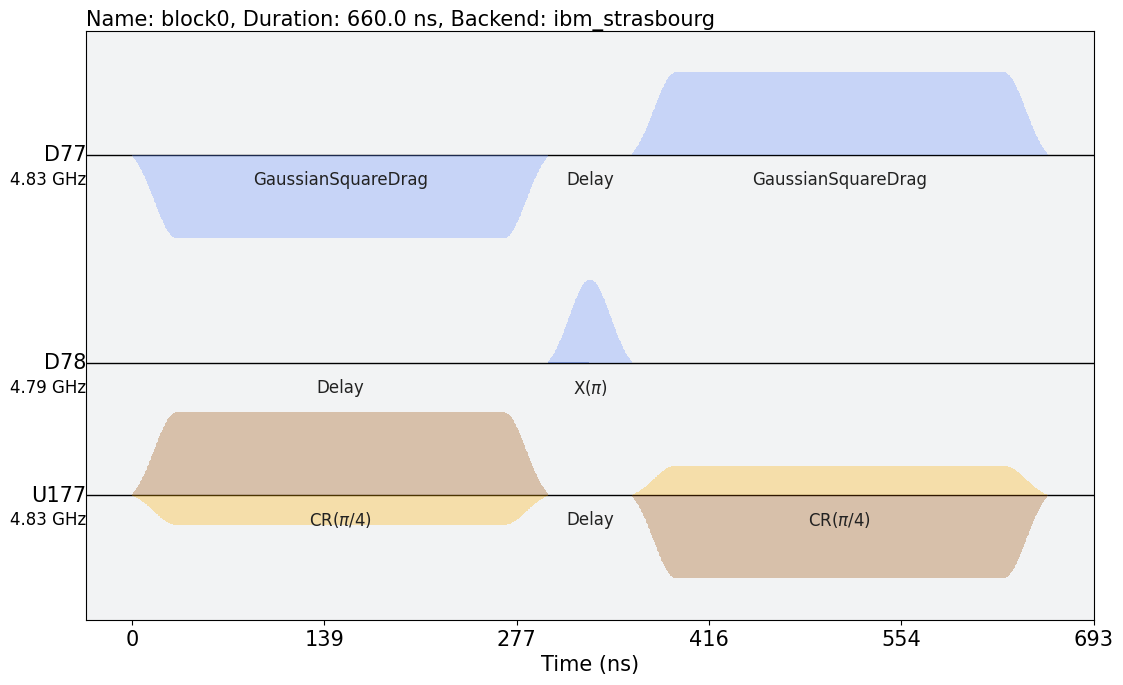

In [13]:
from qiskit import schedule

backend_update.target['ecr'][tuple(config_list[0]['init'])].calibration.draw(backend = backend)

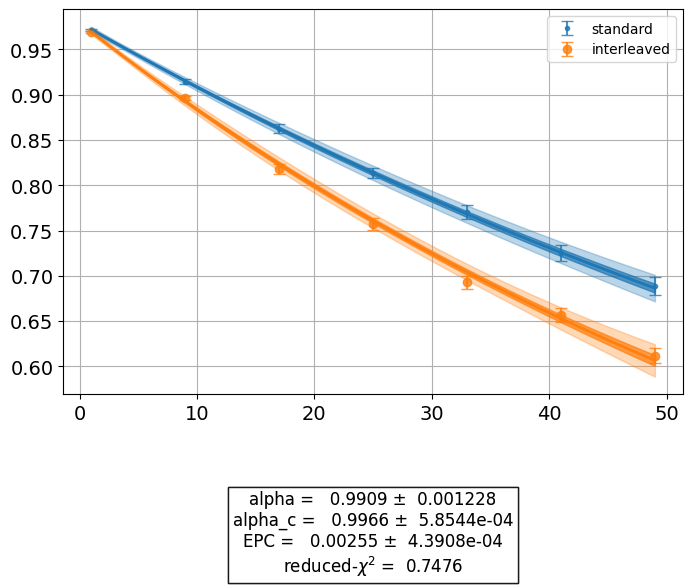

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 50
 - degree of freedom: 10
 - chi-square: 7.476376554834803
 - reduced chi-square: 0.7476376554834803
 - Akaike info crit.: -0.7823270191988172
 - Bayesian info crit.: 1.7739022992622164
 - init params:
  * a = 0.7294064166506673
  * alpha = 0.989700431027666
  * b = 0.25
  * alpha_c = 0.9960451383823749
 - fit params:
  * a = 0.8129960560321353 ± 0.09215134199912822
  * alpha = 0.9909139024073369 ± 0.001228085917726905
  * b = 0.16652507498113261 ± 0.09264437877983904
  * alpha_c = 0.9966006477096357 ± 0.0005854364704145132
 - correlations:
  * (a, b) = -0.9999410995565264
  * (alpha, b) = -0.9901641320118815
  * (b, alpha_c) = -0.9198492150959416
  * (alpha, alpha_c) = 0.8760558164947327
  * (a, alpha_c) = 

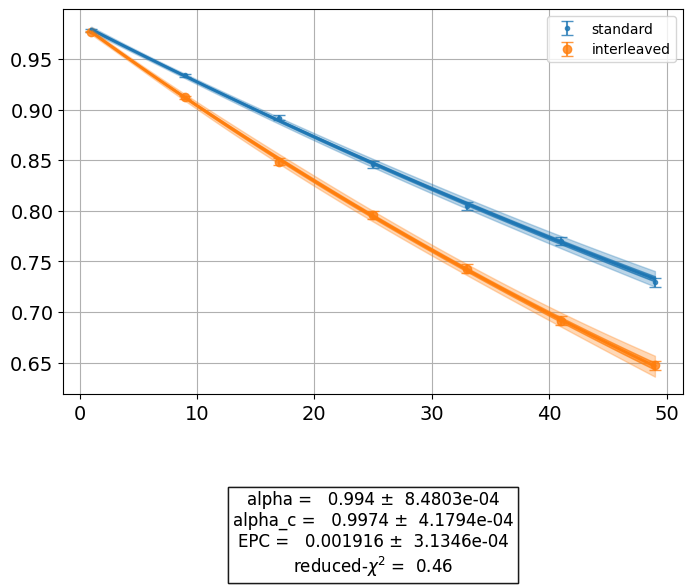

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 96
 - degree of freedom: 10
 - chi-square: 4.599650322658319
 - reduced chi-square: 0.4599650322658319
 - Akaike info crit.: -7.5830786415225955
 - Bayesian info crit.: -5.026849323061562
 - init params:
  * a = 0.7353191993627279
  * alpha = 0.9913370788731801
  * b = 0.25
  * alpha_c = 0.9961243513620085
 - fit params:
  * a = 0.9851466891184647 ± 0.12163122761289742
  * alpha = 0.9939768084691141 ± 0.0008480336988796589
  * b = 6.141617007871335e-20 ± 0.12211953183489467
  * alpha_c = 0.9974459310512165 ± 0.0004179418496601318
 - correlations:
  * (a, b) = -0.9999765146540611
  * (alpha, b) = -0.9965098101626784
  * (b, alpha_c) = -0.9735748375706692
  * (alpha, alpha_c) = 0.9596935126096446
  * (a, alpha_c

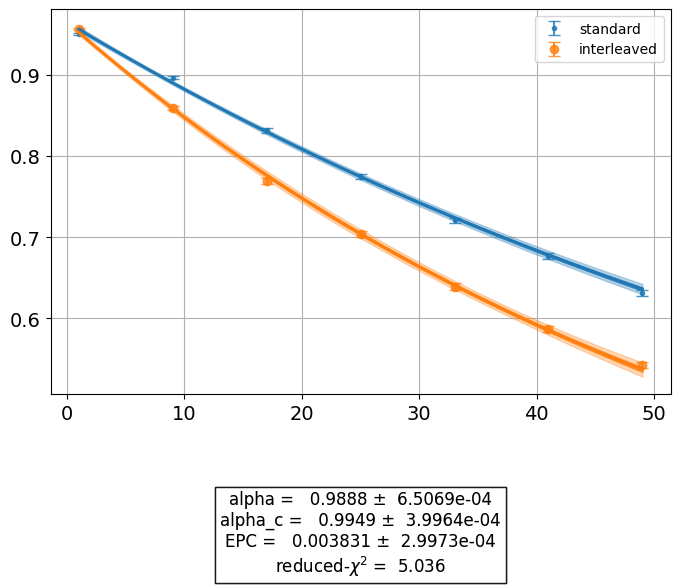

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 40
 - degree of freedom: 10
 - chi-square: 50.35964895207864
 - reduced chi-square: 5.035964895207864
 - Akaike info crit.: 25.92186072274781
 - Bayesian info crit.: 28.478090041208844
 - init params:
  * a = 0.7147515019096777
  * alpha = 0.9874135718651882
  * b = 0.25
  * alpha_c = 0.994264339715501
 - fit params:
  * a = 0.777124205704042 ± 0.03464469401958506
  * alpha = 0.9888075953266627 ± 0.0006506916708259215
  * b = 0.18822809587181988 ± 0.03518722416451159
  * alpha_c = 0.9948916851352613 ± 0.00039964298878965407
 - correlations:
  * (a, b) = -0.9995658230346299
  * (alpha, b) = -0.9889702211109124
  * (b, alpha_c) = -0.9373377959447369
  * (alpha, alpha_c) = 0.9016651144397956
  * (a, alpha_c) = 0.

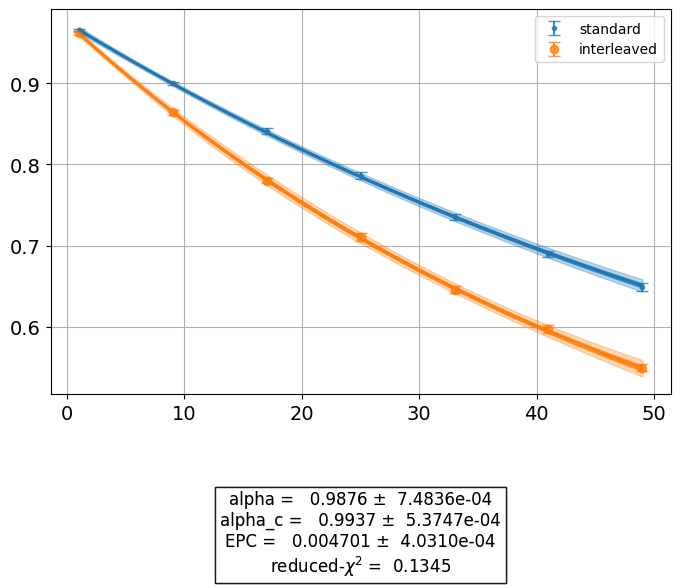

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 30
 - degree of freedom: 10
 - chi-square: 1.3451747255816895
 - reduced chi-square: 0.13451747255816895
 - Akaike info crit.: -24.79546784504234
 - Bayesian info crit.: -22.239238526581303
 - init params:
  * a = 0.7242157314022595
  * alpha = 0.9879288316275029
  * b = 0.25
  * alpha_c = 0.9941591787871807
 - fit params:
  * a = 0.7074460449624572 ± 0.03199506094687223
  * alpha = 0.9876050743526484 ± 0.000748359733825432
  * b = 0.267090619109137 ± 0.03257988486863076
  * alpha_c = 0.9937315431661554 ± 0.0005374723968059027
 - correlations:
  * (a, b) = -0.9992635461937305
  * (alpha, b) = -0.9843417946050633
  * (b, alpha_c) = -0.9318548916452669
  * (alpha, alpha_c) = 0.8863328679817121
  * (a, alpha_c) =

In [25]:
import numpy as np
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
import numpy as np
import pandas as pd
## with angle
lengths = np.arange(1, 50, 8)   
num_samples = 30
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=25)
    int_expdata2 = int_exp2.run(backend_update).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

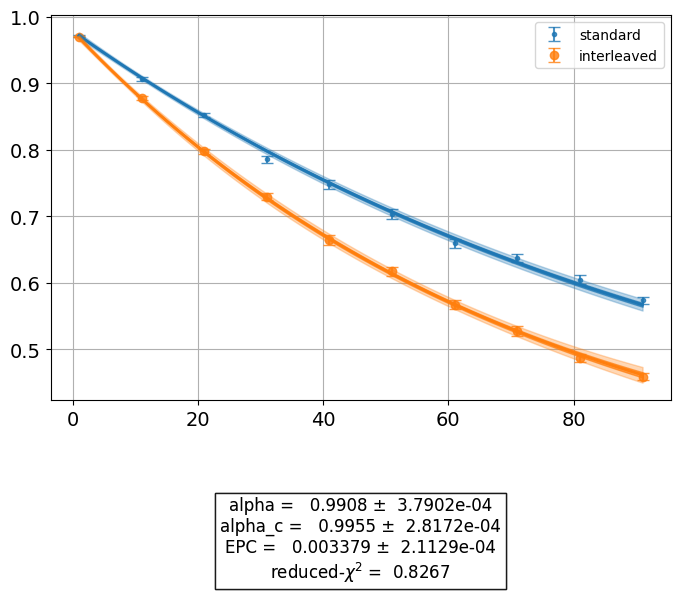

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 25
 - degree of freedom: 16
 - chi-square: 13.227855849839203
 - reduced chi-square: 0.8267409906149502
 - Akaike info crit.: -0.26814751689909855
 - Bayesian info crit.: 3.714781577316865
 - init params:
  * a = 0.7285321162630769
  * alpha = 0.9911416531930849
  * b = 0.25
  * alpha_c = 0.9951836754310579
 - fit params:
  * a = 0.7234976534923746 ± 0.019622196005597697
  * alpha = 0.9908142208966624 ± 0.000379023273339367
  * b = 0.2546753822220723 ± 0.020275577347204185
  * alpha_c = 0.9954952756075878 ± 0.0002817192267845487
 - correlations:
  * (a, b) = -0.9977456261738088
  * (alpha, b) = -0.9652995661976256
  * (b, alpha_c) = -0.8548086740757729
  * (alpha, alpha_c) = 0.7579845886663229
  * (a, alpha_c)

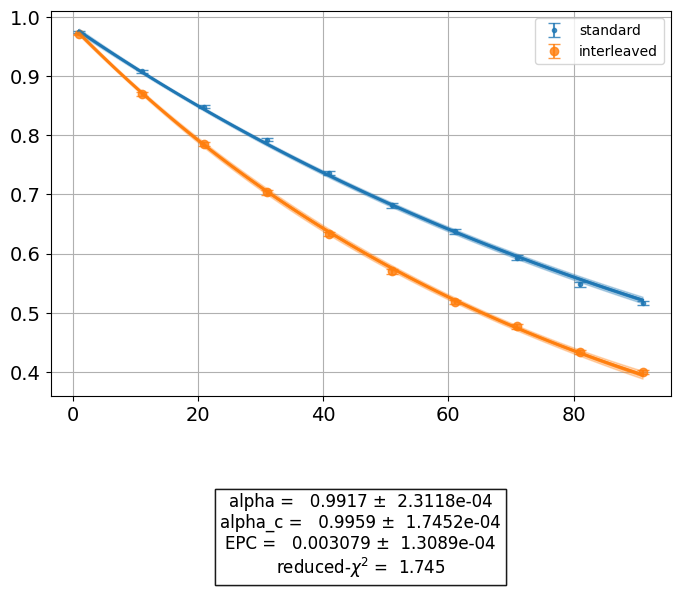

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 55
 - degree of freedom: 16
 - chi-square: 27.91506670835036
 - reduced chi-square: 1.7446916692718974
 - Akaike info crit.: 14.668685898019891
 - Bayesian info crit.: 18.651614992235857
 - init params:
  * a = 0.7330831051280753
  * alpha = 0.9889523192195446
  * b = 0.25
  * alpha_c = 0.9936539615688949
 - fit params:
  * a = 0.8672312547890928 ± 0.016027795988351946
  * alpha = 0.9916669794386156 ± 0.00023117739513767033
  * b = 0.1164242032710582 ± 0.016610104372822954
  * alpha_c = 0.995894040518869 ± 0.00017452359924005636
 - correlations:
  * (a, b) = -0.9970491323693655
  * (alpha, b) = -0.9737321990953703
  * (b, alpha_c) = -0.9146996196206916
  * (alpha, alpha_c) = 0.8427476644837709
  * (a, alpha_c)

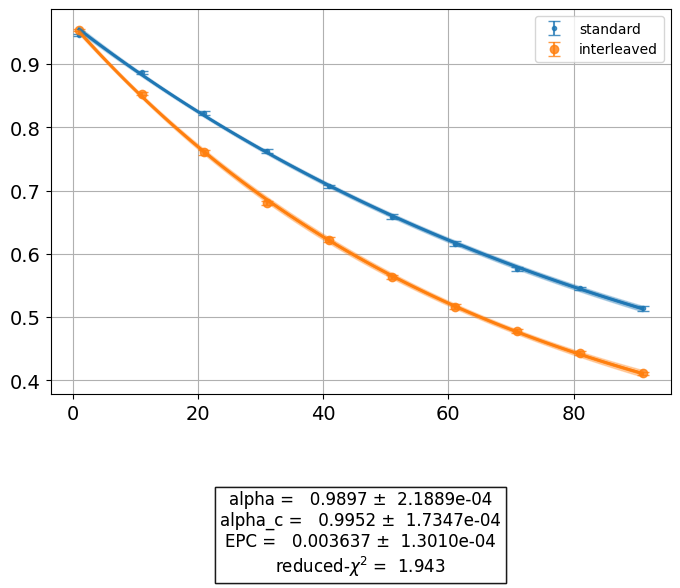

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 35
 - degree of freedom: 16
 - chi-square: 31.087408791355777
 - reduced chi-square: 1.942963049459736
 - Akaike info crit.: 16.82141203276322
 - Bayesian info crit.: 20.804341126979182
 - init params:
  * a = 0.7101426089772349
  * alpha = 0.989259339937944
  * b = 0.25
  * alpha_c = 0.9944285124167896
 - fit params:
  * a = 0.7358337944883135 ± 0.009173587644289282
  * alpha = 0.9896795843883349 ± 0.00021889270989676292
  * b = 0.22698469624746206 ± 0.009743341734837702
  * alpha_c = 0.9951510942678002 ± 0.0001734669794121575
 - correlations:
  * (a, b) = -0.9907739961655969
  * (alpha, b) = -0.9634574450893109
  * (b, alpha_c) = -0.8822603488542867
  * (alpha, alpha_c) = 0.7905369251684551
  * (a, alpha_c) 

In [51]:
import numpy as np
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
import numpy as np
import pandas as pd

lengths = np.arange(1, 100, 10)   
num_samples = 30
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=50)
    int_expdata2 = int_exp2.run(backend).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

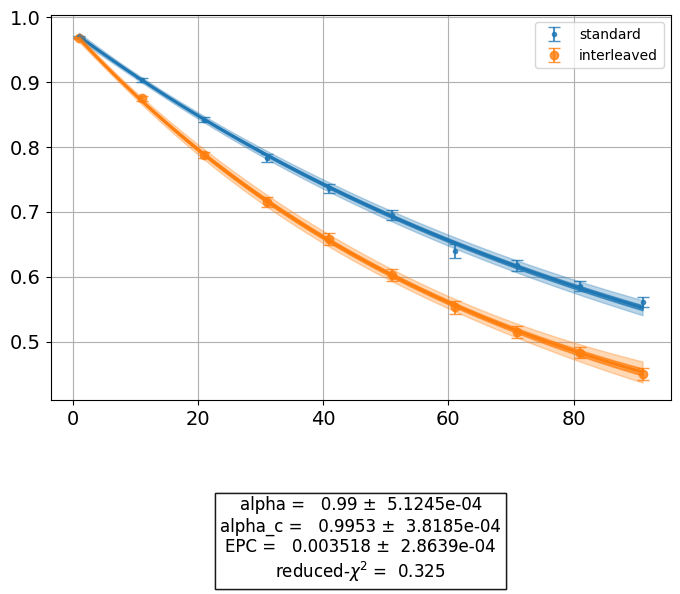

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 30
 - degree of freedom: 16
 - chi-square: 5.199382163823851
 - reduced chi-square: 0.3249613852389907
 - Akaike info crit.: -18.943849393497764
 - Bayesian info crit.: -14.960920299281801
 - init params:
  * a = 0.7275957486043656
  * alpha = 0.9907200292982432
  * b = 0.25
  * alpha_c = 0.9951197962632867
 - fit params:
  * a = 0.7109662263664441 ± 0.023737396423138574
  * alpha = 0.9900083425553032 ± 0.0005124482487187149
  * b = 0.2672034805117078 ± 0.024552428684735627
  * alpha_c = 0.9953099949389596 ± 0.0003818486148386013
 - correlations:
  * (a, b) = -0.9973705385818925
  * (alpha, b) = -0.9644123227827034
  * (b, alpha_c) = -0.8344239865835151
  * (alpha, alpha_c) = 0.7375843085651116
  * (a, alpha_c

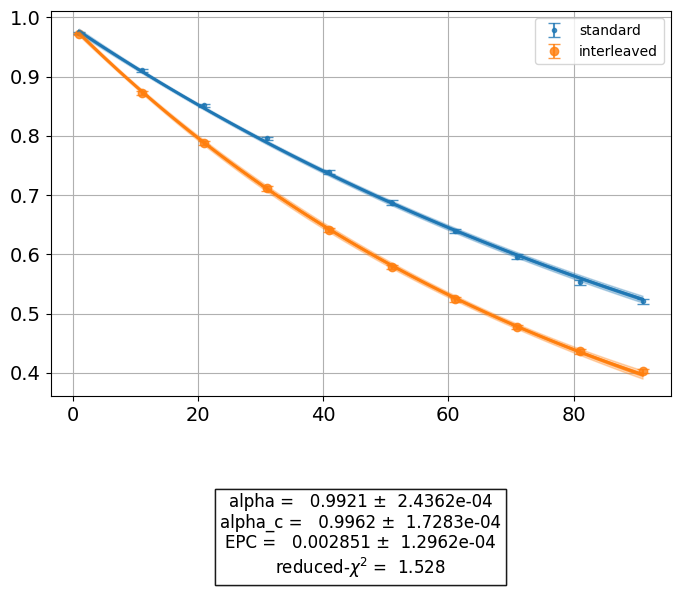

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 66
 - degree of freedom: 16
 - chi-square: 24.44047021157511
 - reduced chi-square: 1.5275293882234444
 - Akaike info crit.: 12.010161999809569
 - Bayesian info crit.: 15.993091094025532
 - init params:
  * a = 0.7331157406157394
  * alpha = 0.9891328065318908
  * b = 0.25
  * alpha_c = 0.993713969712979
 - fit params:
  * a = 0.8936752220637727 ± 0.01876616202765417
  * alpha = 0.9920965385247168 ± 0.00024362253631313822
  * b = 0.09007576490617843 ± 0.019408534363583158
  * alpha_c = 0.9961982346720861 ± 0.00017282859299121124
 - correlations:
  * (a, b) = -0.9976042251852754
  * (alpha, b) = -0.977254065251712
  * (b, alpha_c) = -0.9229373418299663
  * (alpha, alpha_c) = 0.8588370680364311
  * (a, alpha_c) 

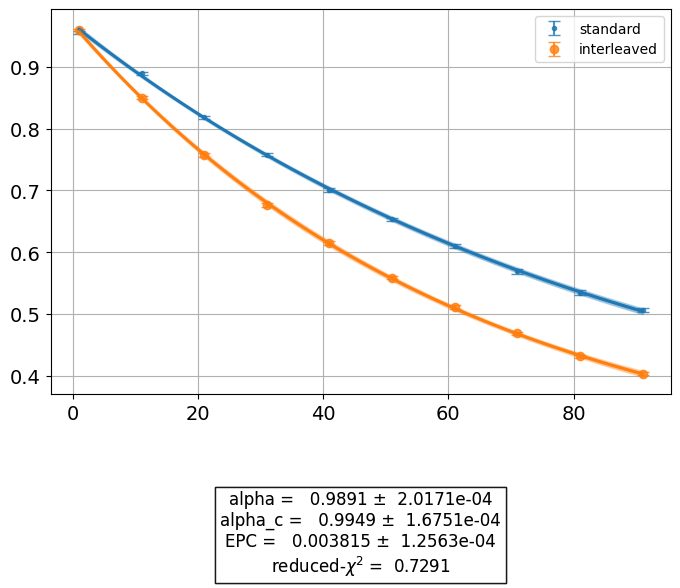

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 30
 - degree of freedom: 16
 - chi-square: 11.665248258603699
 - reduced chi-square: 0.7290780161627312
 - Akaike info crit.: -2.7823617191567944
 - Bayesian info crit.: 1.200567375059169
 - init params:
  * a = 0.7173000856220018
  * alpha = 0.9888440248249201
  * b = 0.25
  * alpha_c = 0.9942401191506492
 - fit params:
  * a = 0.7364473917298343 ± 0.007685227672430772
  * alpha = 0.9891307837042442 ± 0.00020170682460818147
  * b = 0.23226371238726262 ± 0.008216612070275546
  * alpha_c = 0.9949129286671597 ± 0.00016751185324927735
 - correlations:
  * (a, b) = -0.9862994195428743
  * (alpha, b) = -0.9467075644139221
  * (b, alpha_c) = -0.8657809104800875
  * (alpha, alpha_c) = 0.7316538125279661
  * (a, alpha

In [52]:
import numpy as np
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
import numpy as np
import pandas as pd

lengths = np.arange(1, 100, 10)   
num_samples = 30
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=50)
    int_expdata2 = int_exp2.run(backend_update_1).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

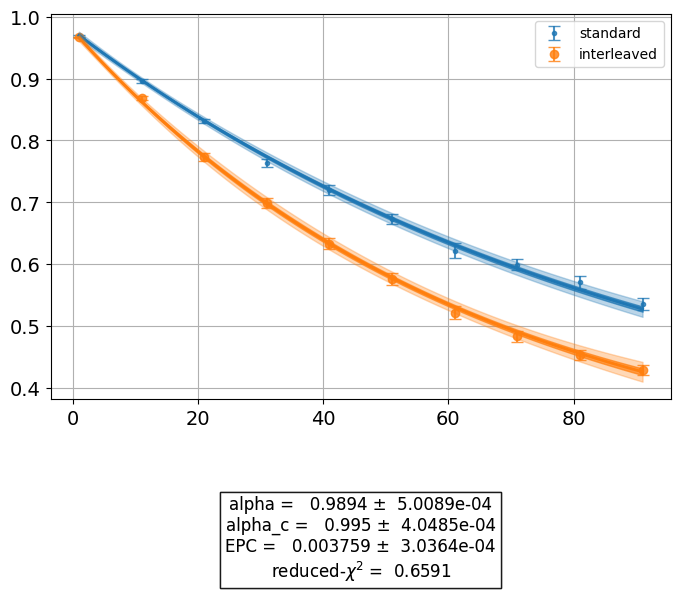

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 25
 - degree of freedom: 16
 - chi-square: 10.545607059932717
 - reduced chi-square: 0.6591004412457948
 - Akaike info crit.: -4.800457855415047
 - Bayesian info crit.: -0.8175287611990836
 - init params:
  * a = 0.7270240577350381
  * alpha = 0.9898122778500151
  * b = 0.25
  * alpha_c = 0.9948490099540981
 - fit params:
  * a = 0.7269164764321844 ± 0.021791338181534475
  * alpha = 0.9894296138770571 ± 0.0005008949390447777
  * b = 0.2508449965773222 ± 0.022617275372484275
  * alpha_c = 0.9949882058324377 ± 0.000404851832316691
 - correlations:
  * (a, b) = -0.9964669032521699
  * (alpha, b) = -0.9531903704878778
  * (b, alpha_c) = -0.827167648640039
  * (alpha, alpha_c) = 0.7043802201874347
  * (a, alpha_c) 

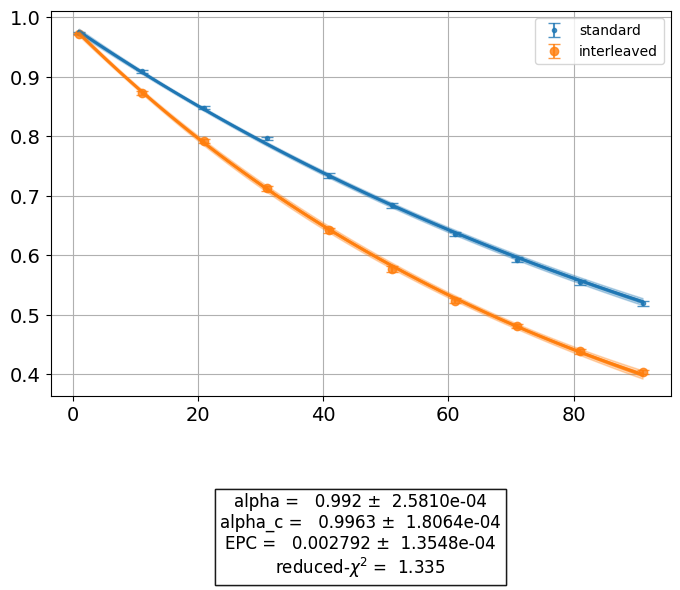

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 60
 - degree of freedom: 16
 - chi-square: 21.358998243455094
 - reduced chi-square: 1.3349373902159434
 - Akaike info crit.: 9.314816814471497
 - Bayesian info crit.: 13.29774590868746
 - init params:
  * a = 0.7329453049788341
  * alpha = 0.9890771431459517
  * b = 0.25
  * alpha_c = 0.9938971487190928
 - fit params:
  * a = 0.8861655603640133 ± 0.019199083147009455
  * alpha = 0.9919605683925523 ± 0.000258095441727922
  * b = 0.09711348583497756 ± 0.019920227136213785
  * alpha_c = 0.9962774215188123 ± 0.00018063750040874218
 - correlations:
  * (a, b) = -0.9974486578038875
  * (alpha, b) = -0.9777358827372068
  * (b, alpha_c) = -0.9219987425305788
  * (alpha, alpha_c) = 0.8593169204916534
  * (a, alpha_c) 

Job was cancelled before completion [Job ID: ctwpyg2v0kkg008q0cng]


ExperimentEntryNotFound: 'Figure index 0 out of range.'

In [53]:
import numpy as np
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits
import numpy as np
import pandas as pd

lengths = np.arange(1, 100, 10)   
num_samples = 30
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=50)
    int_expdata2 = int_exp2.run(backend_update_2).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

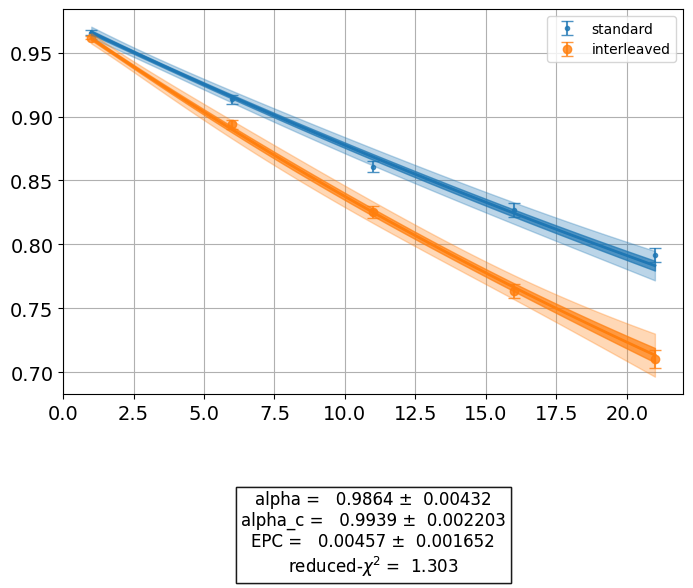

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 45
 - degree of freedom: 6
 - chi-square: 7.820190165723136
 - reduced chi-square: 1.3033650276205226
 - Akaike info crit.: 5.541237791349081
 - Bayesian info crit.: 6.751578163325265
 - init params:
  * a = 0.726382919709961
  * alpha = 0.9862000616137838
  * b = 0.25
  * alpha_c = 0.9921590247430774
 - fit params:
  * a = 0.7734666079271957 ± 0.2157250570927264
  * alpha = 0.9864324363584155 ± 0.004319885958437632
  * b = 0.20282205312030432 ± 0.2167100823479926
  * alpha_c = 0.9939068064178652 ± 0.0022032226331485864
 - correlations:
  * (a, b) = -0.9999763448375106
  * (alpha, b) = -0.9972765730438217
  * (b, alpha_c) = -0.9803320483096671
  * (alpha, alpha_c) = 0.9701358777964065
  * (a, alpha_c) = 0.9802

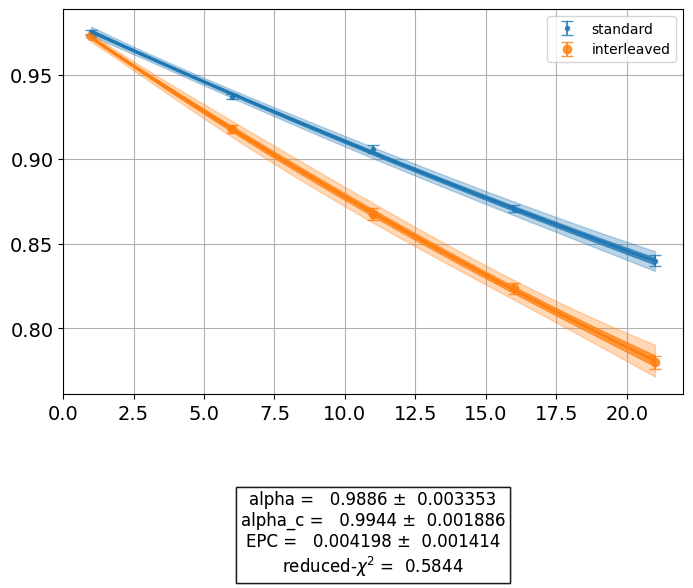

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 67
 - degree of freedom: 6
 - chi-square: 3.5061032487899255
 - reduced chi-square: 0.5843505414649875
 - Akaike info crit.: -2.48079857758648
 - Bayesian info crit.: -1.2704582056102964
 - init params:
  * a = 0.7332920163116243
  * alpha = 0.9897666555648477
  * b = 0.25
  * alpha_c = 0.9947647178741629
 - fit params:
  * a = 0.6728359442154701 ± 0.17776516854476218
  * alpha = 0.9886489477260538 ± 0.0033533229096068154
  * b = 0.31032027547539703 ± 0.17840619198839341
  * alpha_c = 0.9944032280565499 ± 0.0018859337698932178
 - correlations:
  * (a, b) = -0.9999869579252798
  * (alpha, b) = -0.9985098204147765
  * (b, alpha_c) = -0.9893531493019316
  * (alpha, alpha_c) = 0.9846145784407069
  * (a, alpha_c) =

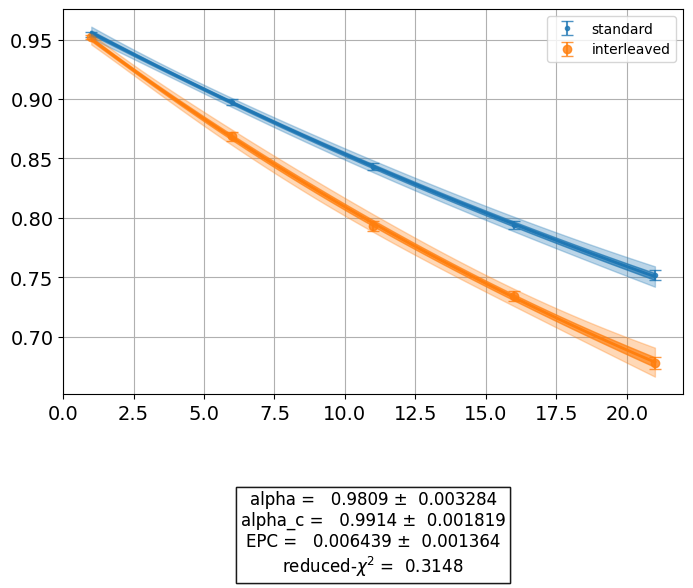

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 56
 - degree of freedom: 6
 - chi-square: 1.8887334077157452
 - reduced chi-square: 0.31478890128595755
 - Akaike info crit.: -8.666786432242485
 - Bayesian info crit.: -7.456446060266302
 - init params:
  * a = 0.7178038598084846
  * alpha = 0.9832111837841587
  * b = 0.25
  * alpha_c = 0.9922624711235353
 - fit params:
  * a = 0.6524252895543922 ± 0.0918207609117323
  * alpha = 0.9808518798722088 ± 0.0032840234110776767
  * b = 0.3159806411397243 ± 0.09288126719768929
  * alpha_c = 0.9914140331482326 ± 0.0018192291718160958
 - correlations:
  * (a, b) = -0.999840471049352
  * (alpha, b) = -0.9948991405758361
  * (b, alpha_c) = -0.9700072982985918
  * (alpha, alpha_c) = 0.953820189946493
  * (a, alpha_c) = 0.

In [ ]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits

## CR 안 건들임
lengths = np.arange(1, 100, 10)     
num_samples = 30
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=50)
    int_expdata2 = int_exp2.run(backend_update).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

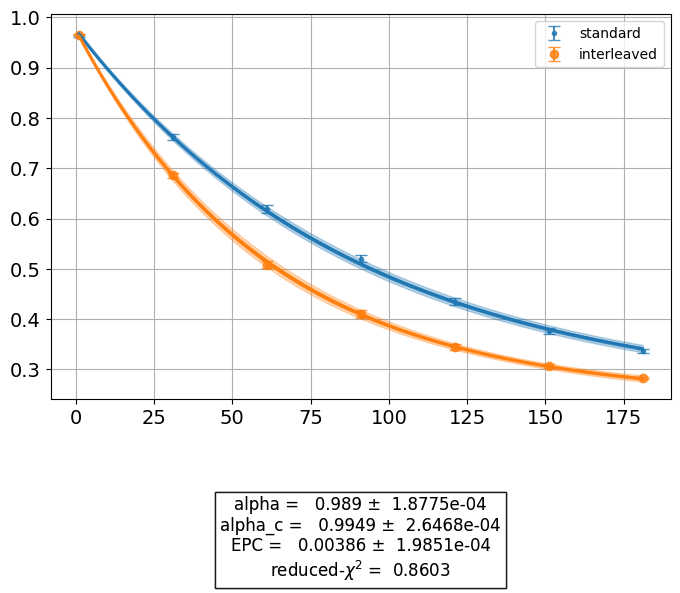

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 25
 - degree of freedom: 10
 - chi-square: 8.602907988527104
 - reduced chi-square: 0.8602907988527104
 - Akaike info crit.: 1.1826013656486873
 - Bayesian info crit.: 3.738830684109721
 - init params:
  * a = 0.7245828504252443
  * alpha = 0.9883805801028508
  * b = 0.25
  * alpha_c = 0.994668278381534
 - fit params:
  * a = 0.731578840514805 ± 0.0040643320847574905
  * alpha = 0.9889505844192527 ± 0.0001877536985148432
  * b = 0.24349580074993726 ± 0.004086847344206282
  * alpha_c = 0.9948529747813637 ± 0.00026467639215353993
 - correlations:
  * (a, b) = -0.9307562284520079
  * (alpha, b) = -0.7524673058348796
  * (b, alpha_c) = -0.6240738376964543
  * (alpha, alpha_c) = 0.17852925884957782
  * (a, alpha_c)

In [8]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits


lengths = np.arange(1, 200, 30)     
num_samples = 30
seed = 1010

for config in config_list:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=100)
    int_expdata2 = int_exp2.run(backend_update).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)

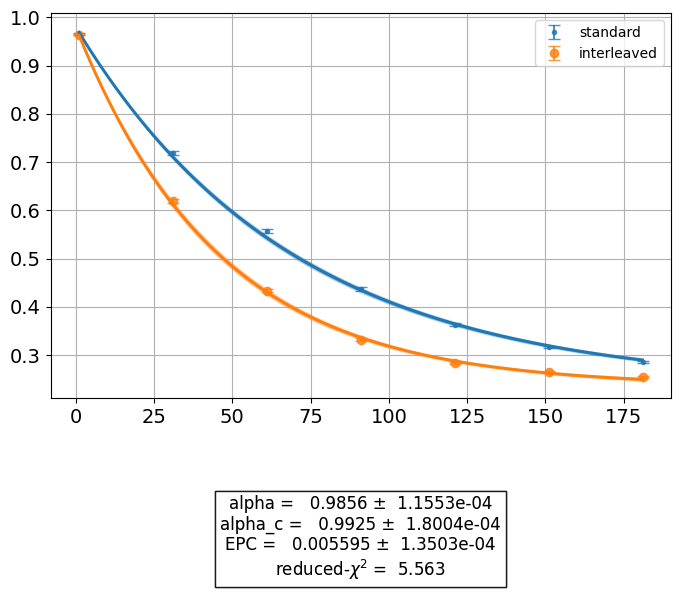

AnalysisResult
- name: @Parameters_InterleavedRBAnalysis
- value: CurveFitResult:
 - fitting method: least_squares
 - number of sub-models: 2
  * F_standard(x) = a * alpha ** x + b
  * F_interleaved(x) = a * (alpha_c * alpha) ** x + b
 - success: True
 - number of function evals: 30
 - degree of freedom: 10
 - chi-square: 55.63123529350735
 - reduced chi-square: 5.563123529350735
 - Akaike info crit.: 27.31562499654381
 - Bayesian info crit.: 29.871854315004846
 - init params:
  * a = 0.7311657517667205
  * alpha = 0.9834728733174553
  * b = 0.25
  * alpha_c = 0.9882999440431598
 - fit params:
  * a = 0.7441109885987894 ± 0.0016390838783988486
  * alpha = 0.9856210346659138 ± 0.00011553128455083431
  * b = 0.23568327950066265 ± 0.001376300996920184
  * alpha_c = 0.9925403870057804 ± 0.00018004464566076606
 - correlations:
  * (a, b) = -0.7184410657237024
  * (alpha, b) = -0.7070080569685427
  * (b, alpha_c) = -0.535966279053455
  * (alpha, alpha_c) = 0.07985745771190181
  * (a, alpha_c

In [9]:
lengths = np.arange(1, 200, 30)
num_samples = 30
seed = 1010

for config in config_list_plus:
    qubits = tuple(config['init'])
    # The interleaved gate is the CX gate
    int_exp2 = InterleavedRB(
        circuits.ECRGate(), qubits, lengths, num_samples=num_samples, seed=seed)
    int_exp2.set_experiment_options(max_circuits=100)
    int_expdata2 = int_exp2.run(backend_update_plus).block_for_results()
    int_results2 = int_expdata2.analysis_results()
    # View result data
    display(int_expdata2.figure(0))
    for result in int_results2:
        print(result)